In [131]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from datetime import datetime, timedelta
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [132]:
import prophet


In [133]:
df = pd.read_csv("../data/CombinedData/combined_aqi_final.csv")
df.set_index(df['Datetime'], inplace=True, drop=True)

In [134]:
df.drop(['Datetime'],inplace=True, axis=1)

In [135]:
alandur = df[df['station'] == 'alandur']
alandur = pd.DataFrame(alandur)
alandur

,Year,Month,Day,station,PM2_5,PM10 (µg/m³),NOx,CO,SO2,Ozone,NOx_SubIndex,SO2_SubIndex,AQI_calculated,PM2_5_24_avg,CO_8_avg,PM2_5_24_avg_Sub_Index,CO_8_avg_Sub_Index,AQI_Bucket,Week,Hour
Datetime,,,,,,,,,,,,,,,,,,,,
2021-01-01 15:00:00,2021,1,1,alandur,28.00,219.03,29.1776,710.0,8.22,14.22,36,10,36.0,20.414375,697.50,34.0,35,Good,53,15
2021-01-01 16:00:00,2021,1,1,alandur,25.52,219.03,29.2340,720.0,8.06,8.88,37,10,37.0,20.714706,700.00,35.0,35,Good,53,16
2021-01-01 17:00:00,2021,1,1,alandur,25.23,219.03,29.3280,700.0,8.19,2.94,37,10,37.0,20.965556,700.00,35.0,35,Good,53,17
2021-01-01 18:00:00,2021,1,1,alandur,25.58,219.03,29.1400,700.0,8.33,1.10,36,10,36.0,21.208421,701.25,35.0,35,Good,53,18
2021-01-01 19:00:00,2021,1,1,alandur,24.77,219.03,29.1776,700.0,8.06,1.10,36,10,36.0,21.386500,701.25,36.0,35,Good,53,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-20 19:00:00,2024,10,20,alandur,46.91,91.78,27.3916,540.0,4.20,8.48,34,5,96.0,57.783333,481.25,96.0,24,Satisfactory,42,19
2024-10-20 20:00:00,2024,10,20,alandur,38.97,77.20,28.1248,440.0,4.20,8.56,35,5,96.0,57.324583,475.00,96.0,24,Satisfactory,42,20
2024-10-20 21:00:00,2024,10,20,alandur,41.14,80.98,29.3844,500.0,4.20,8.37,37,5,95.0,56.785417,478.75,95.0,24,Satisfactory,42,21


In [136]:
alandur['PM2_5_24_avg_Sub_Index'] = alandur['PM2_5_24_avg_Sub_Index'].astype(int)
alandur['AQI_calculated'] = alandur['AQI_calculated'].astype(int)

In [137]:
alandur.index = pd.to_datetime(alandur.index)
alandur.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33321 entries, 2021-01-01 15:00:00 to 2024-10-20 23:00:00
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    33321 non-null  int64  
 1   Month                   33321 non-null  int64  
 2   Day                     33321 non-null  int64  
 3   station                 33321 non-null  object 
 4   PM2_5                   33321 non-null  float64
 5   PM10 (µg/m³)            33321 non-null  float64
 6   NOx                     33321 non-null  float64
 7   CO                      33321 non-null  float64
 8   SO2                     33321 non-null  float64
 9   Ozone                   33321 non-null  float64
 10  NOx_SubIndex            33321 non-null  int64  
 11  SO2_SubIndex            33321 non-null  int64  
 12  AQI_calculated          33321 non-null  int64  
 13  PM2_5_24_avg            33321 non-null  float64
 14  CO_

Text(0.5, 1.0, 'alandur AQI 2016 - 2023')

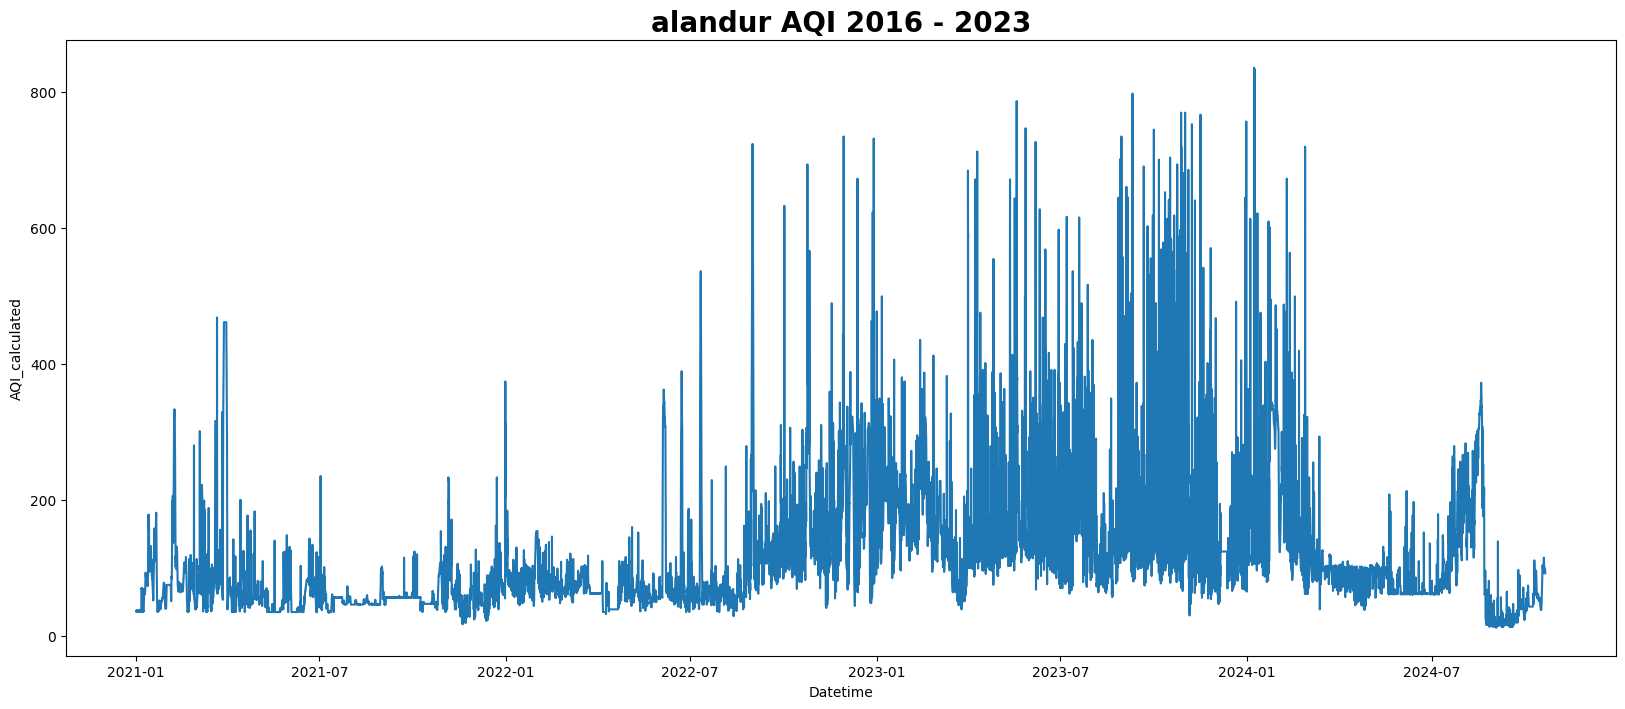

In [138]:
plt.figure(figsize=(20,8))
sns.lineplot(data = alandur['AQI_calculated'], errorbar=None)
plt.title('alandur AQI 2016 - 2023', fontdict= {"fontsize": 20, "fontweight": "bold"})

In [139]:
alandur = alandur[[
    'PM2_5', 'PM2_5_24_avg', 'Day', 'Month', 'Year', 'Week', 'Hour',
    'PM2_5_24_avg_Sub_Index', 'AQI_calculated'
]]
alandur

,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated
Datetime,,,,,,,,,
2021-01-01 15:00:00,28.00,20.414375,1,1,2021,53,15,34,36
2021-01-01 16:00:00,25.52,20.714706,1,1,2021,53,16,35,37
2021-01-01 17:00:00,25.23,20.965556,1,1,2021,53,17,35,37
2021-01-01 18:00:00,25.58,21.208421,1,1,2021,53,18,35,36
2021-01-01 19:00:00,24.77,21.386500,1,1,2021,53,19,36,36
...,...,...,...,...,...,...,...,...,...
2024-10-20 19:00:00,46.91,57.783333,20,10,2024,42,19,96,96
2024-10-20 20:00:00,38.97,57.324583,20,10,2024,42,20,96,96
2024-10-20 21:00:00,41.14,56.785417,20,10,2024,42,21,95,95


In [140]:
alandur['AQI_first_diff'] = alandur['AQI_calculated'].diff()[1:]
alandur['PM2_5_first_diff'] = alandur['PM2_5'].diff()[1:]
alandur

/tmp/ipykernel_27763/240498274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alandur['AQI_first_diff'] = alandur['AQI_calculated'].diff()[1:]
/tmp/ipykernel_27763/240498274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alandur['PM2_5_first_diff'] = alandur['PM2_5'].diff()[1:]


,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated,AQI_first_diff,PM2_5_first_diff
Datetime,,,,,,,,,,,
2021-01-01 15:00:00,28.00,20.414375,1,1,2021,53,15,34,36,NaN,NaN
2021-01-01 16:00:00,25.52,20.714706,1,1,2021,53,16,35,37,1.0,-2.48
2021-01-01 17:00:00,25.23,20.965556,1,1,2021,53,17,35,37,0.0,-0.29
2021-01-01 18:00:00,25.58,21.208421,1,1,2021,53,18,35,36,-1.0,0.35
2021-01-01 19:00:00,24.77,21.386500,1,1,2021,53,19,36,36,0.0,-0.81
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-20 19:00:00,46.91,57.783333,20,10,2024,42,19,96,96,-1.0,-2.17
2024-10-20 20:00:00,38.97,57.324583,20,10,2024,42,20,96,96,0.0,-7.94
2024-10-20 21:00:00,41.14,56.785417,20,10,2024,42,21,95,95,-1.0,2.17


In [141]:
alandur.dropna(inplace=True)

/tmp/ipykernel_27763/2107624478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alandur.dropna(inplace=True)


Datetime
2021-01-01 16:00:00   -11.360388
2021-01-01 17:00:00    -9.917300
2021-01-01 18:00:00    -6.381927
2021-01-01 19:00:00    -4.010922
2021-01-01 20:00:00    -3.479124
Name: seasonal, dtype: float64


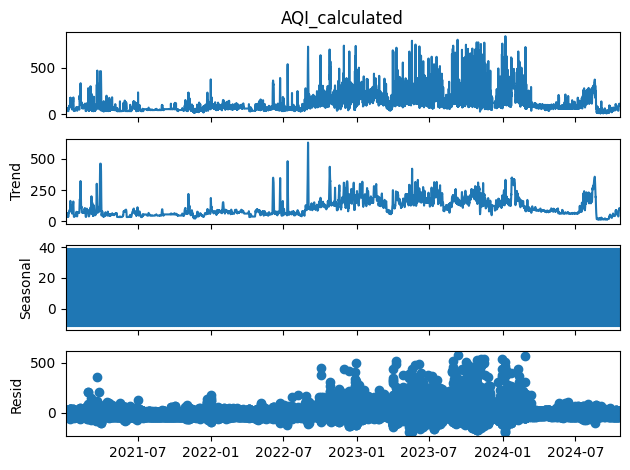

In [142]:
import statsmodels.api as sm

# Run seasonal decompose
decomp = sm.tsa.seasonal_decompose(alandur['AQI_calculated']) # capturing the yearly seasonal component; i.e. for example 
#... every July the energy consumption is high and then it gets lower during the winter months. 
#...So, a periodicity of 24hours*365 was used here.

print(decomp.seasonal.head()) # checking the seasonal component
_ = decomp.plot()

In [143]:
from statsmodels.tsa.stattools import adfuller
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print("# lags used", result[2])
    print("critical values", result[4]) 

In [144]:
perform_adf_test(alandur['AQI_calculated'])

ADF Statistic: -10.611246
p-value: 0.000000
# lags used 51
critical values {'1%': np.float64(-3.430546579434914), '5%': np.float64(-2.861626883110065), '10%': np.float64(-2.566816245173605)}


# Prophet - hourly data

In [145]:
from prophet import Prophet

In [146]:
dir(Prophet)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 'piecewise_logistic'

In [147]:
# Create a new df
alandur_prophet = alandur.copy()
alandur_prophet

,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated,AQI_first_diff,PM2_5_first_diff
Datetime,,,,,,,,,,,
2021-01-01 16:00:00,25.52,20.714706,1,1,2021,53,16,35,37,1.0,-2.48
2021-01-01 17:00:00,25.23,20.965556,1,1,2021,53,17,35,37,0.0,-0.29
2021-01-01 18:00:00,25.58,21.208421,1,1,2021,53,18,35,36,-1.0,0.35
2021-01-01 19:00:00,24.77,21.386500,1,1,2021,53,19,36,36,0.0,-0.81
2021-01-01 20:00:00,23.44,21.484286,1,1,2021,53,20,36,36,0.0,-1.33
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-20 19:00:00,46.91,57.783333,20,10,2024,42,19,96,96,-1.0,-2.17
2024-10-20 20:00:00,38.97,57.324583,20,10,2024,42,20,96,96,0.0,-7.94
2024-10-20 21:00:00,41.14,56.785417,20,10,2024,42,21,95,95,-1.0,2.17


In [148]:
alandur_prophet = alandur_prophet.reset_index()
alandur_prophet

,Datetime,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated,AQI_first_diff,PM2_5_first_diff
0,2021-01-01 16:00:00,25.52,20.714706,1,1,2021,53,16,35,37,1.0,-2.48
1,2021-01-01 17:00:00,25.23,20.965556,1,1,2021,53,17,35,37,0.0,-0.29
2,2021-01-01 18:00:00,25.58,21.208421,1,1,2021,53,18,35,36,-1.0,0.35
3,2021-01-01 19:00:00,24.77,21.386500,1,1,2021,53,19,36,36,0.0,-0.81
4,2021-01-01 20:00:00,23.44,21.484286,1,1,2021,53,20,36,36,0.0,-1.33
...,...,...,...,...,...,...,...,...,...,...,...,...
33315,2024-10-20 19:00:00,46.91,57.783333,20,10,2024,42,19,96,96,-1.0,-2.17
33316,2024-10-20 20:00:00,38.97,57.324583,20,10,2024,42,20,96,96,0.0,-7.94
33317,2024-10-20 21:00:00,41.14,56.785417,20,10,2024,42,21,95,95,-1.0,2.17
33318,2024-10-20 22:00:00,43.38,56.272917,20,10,2024,42,22,94,94,-1.0,2.24


In [149]:
alandur_prophet = alandur_prophet[['Datetime', 'AQI_calculated']]
alandur_prophet

,Datetime,AQI_calculated
0,2021-01-01 16:00:00,37
1,2021-01-01 17:00:00,37
2,2021-01-01 18:00:00,36
3,2021-01-01 19:00:00,36
4,2021-01-01 20:00:00,36
...,...,...
33315,2024-10-20 19:00:00,96
33316,2024-10-20 20:00:00,96
33317,2024-10-20 21:00:00,95
33318,2024-10-20 22:00:00,94


In [150]:
int(len(alandur_prophet)*.80)

26656

In [151]:
int(len(alandur_prophet)*.20)

6664

In [152]:
alandur_prophet.rename(columns={"Datetime": "ds", "AQI_calculated":"y"}, inplace=True)

/tmp/ipykernel_27763/653836216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alandur_prophet.rename(columns={"Datetime": "ds", "AQI_calculated":"y"}, inplace=True)


In [153]:
alandur_prophet_train = alandur_prophet[:int(len(alandur_prophet)*.80)]
alandur_prophet_train

,ds,y
0,2021-01-01 16:00:00,37
1,2021-01-01 17:00:00,37
2,2021-01-01 18:00:00,36
3,2021-01-01 19:00:00,36
4,2021-01-01 20:00:00,36
...,...,...
26651,2024-01-17 03:00:00,183
26652,2024-01-17 04:00:00,165
26653,2024-01-17 05:00:00,151
26654,2024-01-17 06:00:00,324


In [154]:
alandur_prophet_test = alandur_prophet[int(len(alandur_prophet)*.80):]
alandur_prophet_test

,ds,y
26656,2024-01-17 08:00:00,254
26657,2024-01-17 09:00:00,201
26658,2024-01-17 10:00:00,130
26659,2024-01-17 11:00:00,93
26660,2024-01-17 12:00:00,93
...,...,...
33315,2024-10-20 19:00:00,96
33316,2024-10-20 20:00:00,96
33317,2024-10-20 21:00:00,95
33318,2024-10-20 22:00:00,94


In [155]:
alandur_prophet_test

,ds,y
26656,2024-01-17 08:00:00,254
26657,2024-01-17 09:00:00,201
26658,2024-01-17 10:00:00,130
26659,2024-01-17 11:00:00,93
26660,2024-01-17 12:00:00,93
...,...,...
33315,2024-10-20 19:00:00,96
33316,2024-10-20 20:00:00,96
33317,2024-10-20 21:00:00,95
33318,2024-10-20 22:00:00,94


Text(0.5, 1.0, 'Train and test split')

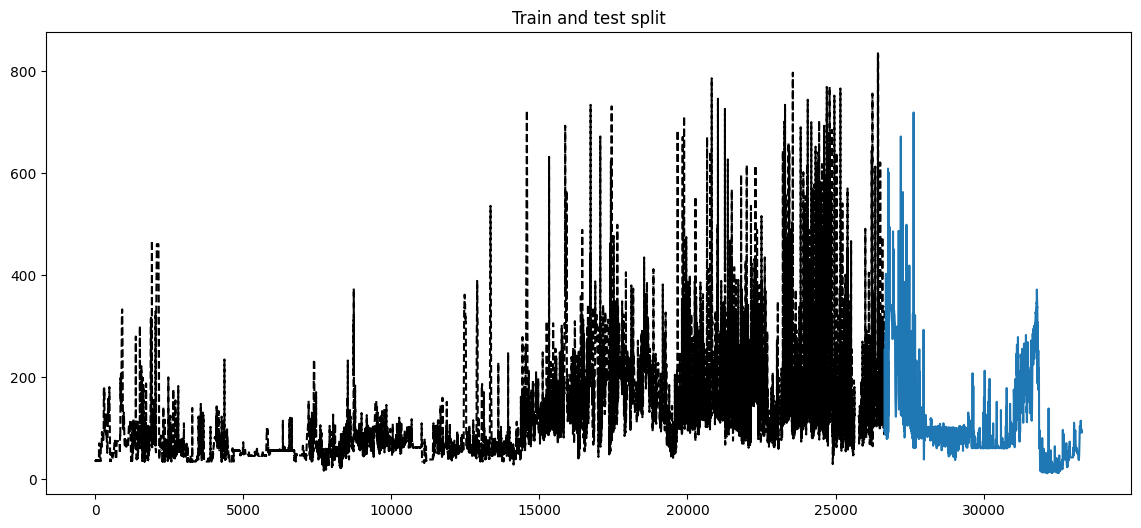

In [156]:
plt.figure(figsize=(14,6))
plt.plot(alandur_prophet_train['y'] ,'k--')
plt.plot(alandur_prophet_test['y'] )
plt.title("Train and test split")

In [157]:
# Initialize the Model
model=Prophet()
model.fit(alandur_prophet_train)

09:44:57 - cmdstanpy - INFO - Chain [1] start processing
09:45:20 - cmdstanpy - INFO - Chain [1] done processing


In [158]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'daily',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [159]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [160]:
future_dates.tail()

,ds
27016,2025-01-12 07:00:00
27017,2025-01-13 07:00:00
27018,2025-01-14 07:00:00
27019,2025-01-15 07:00:00
27020,2025-01-16 07:00:00


In [161]:
prediction=model.predict(future_dates)

In [162]:
prediction = model.predict(alandur_prophet_test)

In [163]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-17 08:00:00,140.758928,97.300608,268.088393,140.758928,140.758928,39.413524,39.413524,39.413524,12.917979,...,3.051363,3.051363,3.051363,23.444182,23.444182,23.444182,0.0,0.0,0.0,180.172452
1,2024-01-17 09:00:00,140.748721,79.764845,247.919352,140.748721,140.748721,24.968666,24.968666,24.968666,-1.683244,...,3.242846,3.242846,3.242846,23.409064,23.409064,23.409064,0.0,0.0,0.0,165.717387
2,2024-01-17 10:00:00,140.738515,69.823205,246.036969,140.738515,140.738515,16.764640,16.764640,16.764640,-10.041720,...,3.432578,3.432578,3.432578,23.373782,23.373782,23.373782,0.0,0.0,0.0,157.503155
3,2024-01-17 11:00:00,140.728308,80.805408,244.261572,140.728308,140.728308,16.059375,16.059375,16.059375,-10.897945,...,3.618981,3.618981,3.618981,23.338339,23.338339,23.338339,0.0,0.0,0.0,156.787683
4,2024-01-17 12:00:00,140.718102,67.594987,246.792041,140.718102,140.718102,18.290033,18.290033,18.290033,-8.813124,...,3.800421,3.800421,3.800421,23.302736,23.302736,23.302736,0.0,0.0,0.0,159.008135


In [164]:
alandur_prophet_test['y']

26656    254
26657    201
26658    130
26659     93
26660     93
        ... 
33315     96
33316     96
33317     95
33318     94
33319     92
Name: y, Length: 6664, dtype: int64

In [165]:
prediction['yhat'] = prediction['yhat'].astype(int)

In [166]:
residuals = alandur_prophet_test['y'].values - prediction['yhat'].values
residuals

array([ 74,  36, -27, ...,  -5,  -9, -15], shape=(6664,))

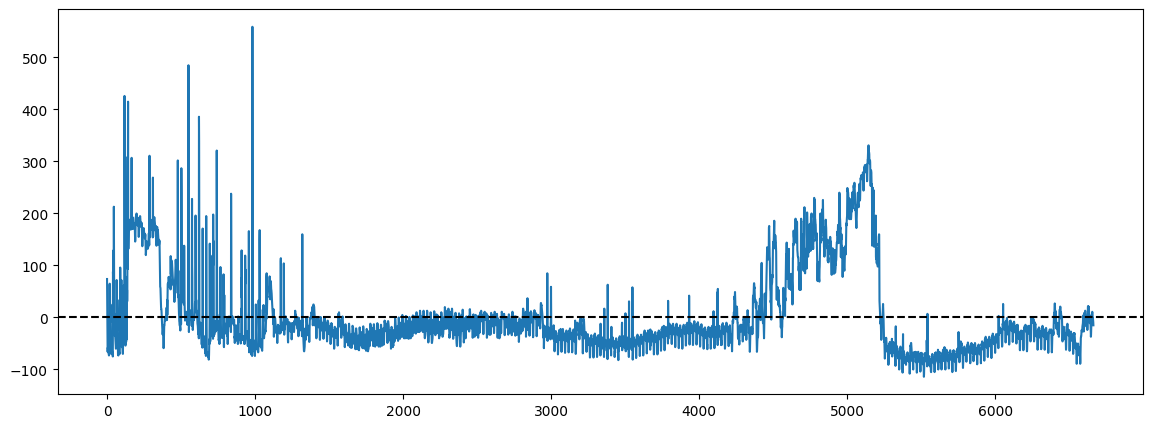

In [167]:
plt.figure(figsize=(14,5))
plt.plot(residuals)
# plt.axhline(0,'k--')
plt.axhline(0, linestyle='--', color='k')

Text(0.5, 1.0, 'Prophet actual vs predicted')

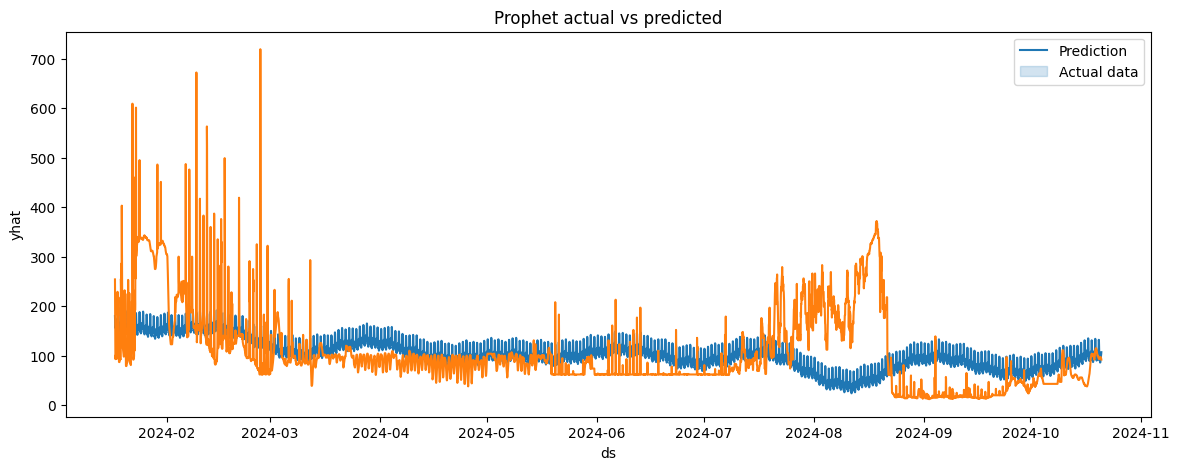

In [168]:
plt.figure(figsize=(14,5))
# plt.plot(prediction['yhat'],'k--')
# plt.plot(alandur_prophet_test['y'])
sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_test, x='ds', y='y')
plt.legend(('Prediction','Actual data'))
plt.title("Prophet actual vs predicted")

In [169]:
plt.figure(figsize=(14,5))
sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_test, x='ds', y='y')
sns.lineplot(data = prediction, x='ds', y='yhat_lower')
sns.lineplot(data = prediction, x='ds', y='yhat_upper')
# plt.legend("Prophet actual vs predicted")

<Axes: xlabel='ds', ylabel='yhat'>

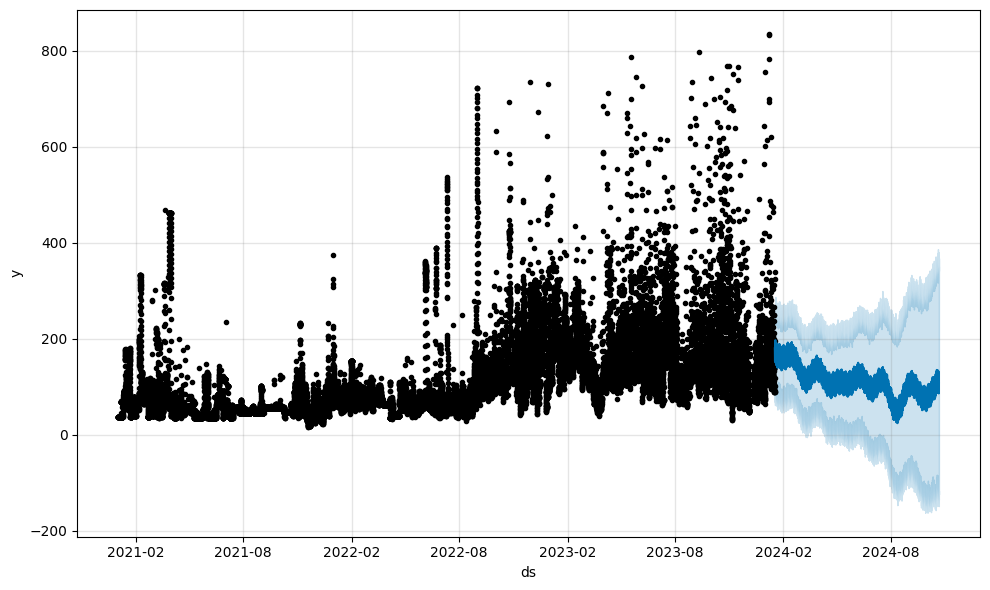

In [170]:
### plot the predicted projection
plot = model.plot(prediction)

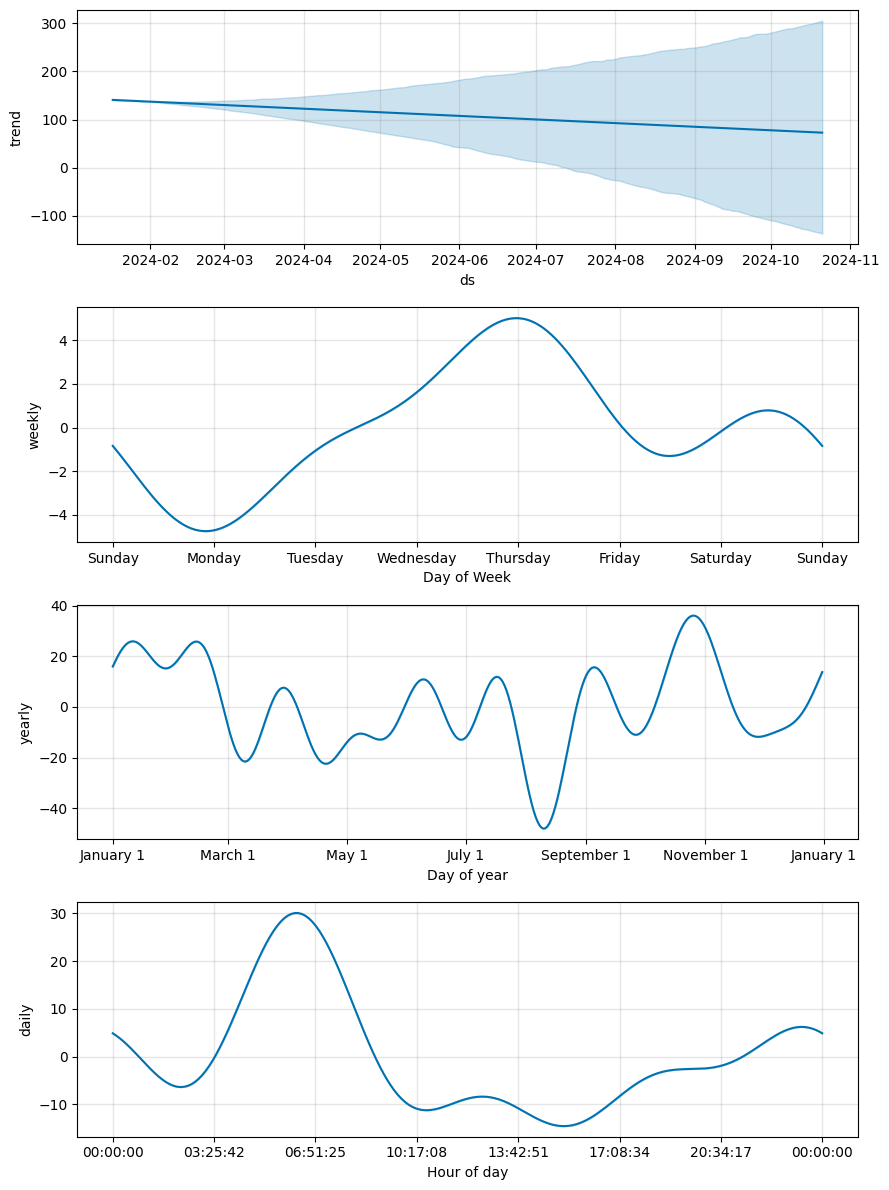

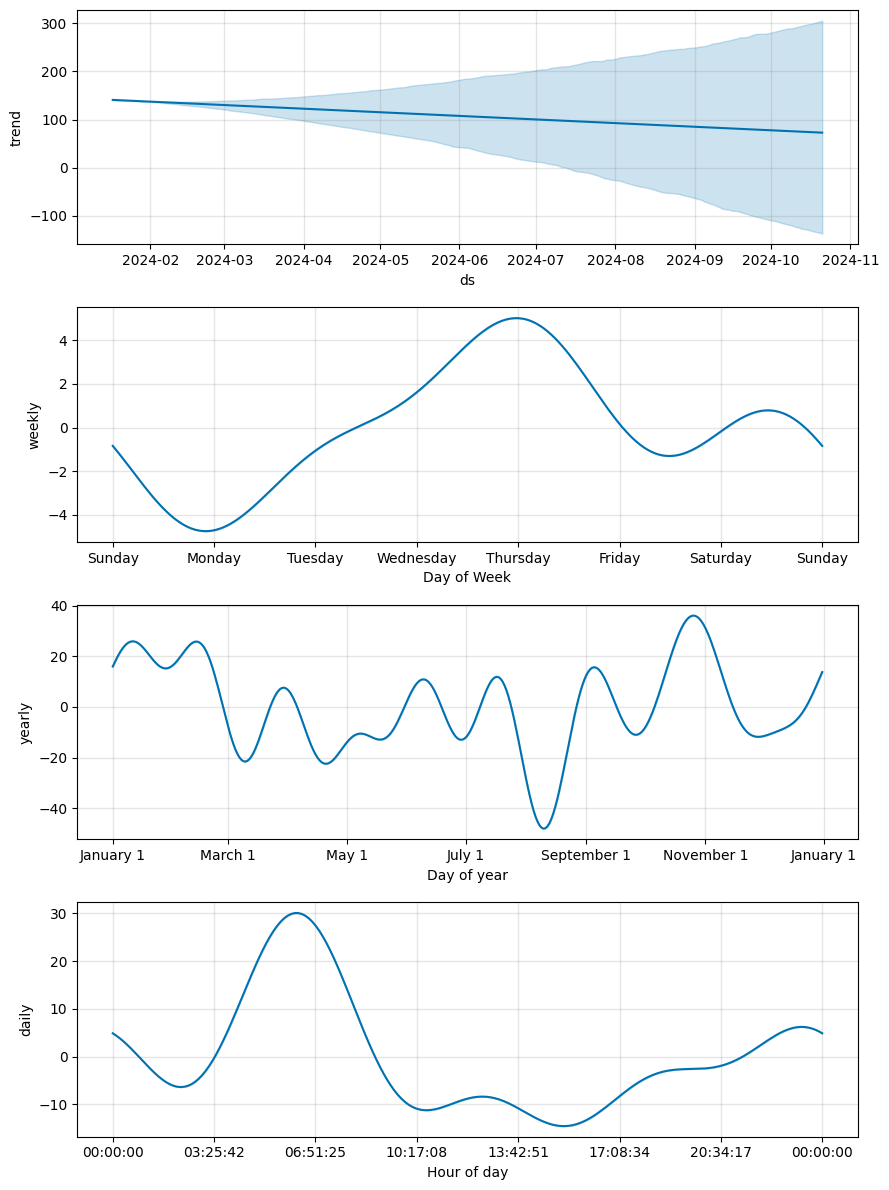

In [171]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [172]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

  0%|          | 0/1 [00:00<?, ?it/s]

09:45:45 - cmdstanpy - INFO - Chain [1] start processing
09:46:02 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-01-17 08:00:00,217.675226,142.410466,282.812626,135,2023-01-17 07:00:00
1,2023-01-17 09:00:00,213.263111,143.750105,288.518140,113,2023-01-17 07:00:00
2,2023-01-17 10:00:00,211.228526,143.256586,291.620381,100,2023-01-17 07:00:00
3,2023-01-17 11:00:00,211.546718,137.838560,279.614841,100,2023-01-17 07:00:00
4,2023-01-17 12:00:00,212.620957,134.774054,282.694998,99,2023-01-17 07:00:00


In [173]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days 12:00:00,3632.509431,60.270303,51.127853,0.314239,0.242501,0.260057,0.732877
1,36 days 13:00:00,3625.868351,60.215184,51.069890,0.313738,0.242132,0.259704,0.734018
2,36 days 14:00:00,3615.448603,60.128601,50.990153,0.312911,0.241852,0.259174,0.735160
3,36 days 15:00:00,3602.208677,60.018403,50.894931,0.311808,0.241729,0.258513,0.736301
4,36 days 16:00:00,3588.652409,59.905362,50.794786,0.310674,0.241577,0.257827,0.737443


/home/codespace/.python/current/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/codespace/.python/current/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


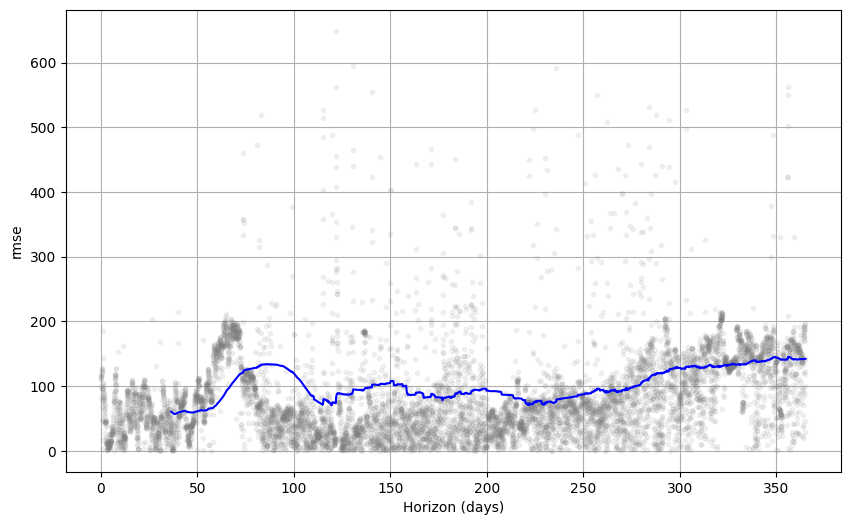

In [174]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

# Prophet - daily data

In [175]:
alandur_daily = alandur.copy()
alandur_daily = alandur_daily.resample('D').mean()
alandur_daily

,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated,AQI_first_diff,PM2_5_first_diff
Datetime,,,,,,,,,,,
2021-01-01,22.780000,21.221887,1.0,1.0,2021.0,53.0,19.5,35.500000,36.375000,0.000000,-1.360000
2021-01-02,19.524167,20.516806,2.0,1.0,2021.0,53.0,11.5,34.250000,36.333333,0.000000,-0.042083
2021-01-03,15.239583,17.688576,3.0,1.0,2021.0,53.0,11.5,29.416667,36.458333,0.000000,-0.134167
2021-01-04,14.137083,14.147188,4.0,1.0,2021.0,1.0,11.5,23.500000,36.375000,0.000000,0.150417
2021-01-05,7.807917,11.713333,5.0,1.0,2021.0,1.0,11.5,19.541667,36.583333,0.000000,-0.415000
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-16,22.876250,24.166632,16.0,10.0,2024.0,42.0,11.5,40.250000,40.250000,-0.291667,0.111250
2024-10-17,56.269167,35.539583,17.0,10.0,2024.0,42.0,11.5,59.375000,59.375000,2.333333,2.452917
2024-10-18,55.230000,59.524549,18.0,10.0,2024.0,42.0,11.5,99.833333,99.833333,-0.083333,-0.962083


In [176]:
# Initialize the Model
model=Prophet()

In [177]:
# Create a new df
alandur_prophet_daily = alandur_daily.copy()
alandur_prophet_daily

,PM2_5,PM2_5_24_avg,Day,Month,Year,Week,Hour,PM2_5_24_avg_Sub_Index,AQI_calculated,AQI_first_diff,PM2_5_first_diff
Datetime,,,,,,,,,,,
2021-01-01,22.780000,21.221887,1.0,1.0,2021.0,53.0,19.5,35.500000,36.375000,0.000000,-1.360000
2021-01-02,19.524167,20.516806,2.0,1.0,2021.0,53.0,11.5,34.250000,36.333333,0.000000,-0.042083
2021-01-03,15.239583,17.688576,3.0,1.0,2021.0,53.0,11.5,29.416667,36.458333,0.000000,-0.134167
2021-01-04,14.137083,14.147188,4.0,1.0,2021.0,1.0,11.5,23.500000,36.375000,0.000000,0.150417
2021-01-05,7.807917,11.713333,5.0,1.0,2021.0,1.0,11.5,19.541667,36.583333,0.000000,-0.415000
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-16,22.876250,24.166632,16.0,10.0,2024.0,42.0,11.5,40.250000,40.250000,-0.291667,0.111250
2024-10-17,56.269167,35.539583,17.0,10.0,2024.0,42.0,11.5,59.375000,59.375000,2.333333,2.452917
2024-10-18,55.230000,59.524549,18.0,10.0,2024.0,42.0,11.5,99.833333,99.833333,-0.083333,-0.962083


In [178]:
alandur_prophet_daily = alandur_prophet_daily.reset_index()


In [179]:
alandur_prophet_daily = alandur_prophet_daily[['Datetime', 'AQI_calculated']]

In [180]:
alandur_prophet_daily.rename(columns={"Datetime": "ds", "AQI_calculated":"y"}, inplace=True)

In [181]:
alandur_prophet_daily

,ds,y
0,2021-01-01,36.375000
1,2021-01-02,36.333333
2,2021-01-03,36.458333
3,2021-01-04,36.375000
4,2021-01-05,36.583333
...,...,...
1384,2024-10-16,40.250000
1385,2024-10-17,59.375000
1386,2024-10-18,99.833333
1387,2024-10-19,106.458333


In [182]:
model.fit(alandur_prophet)

09:46:32 - cmdstanpy - INFO - Chain [1] start processing
09:47:26 - cmdstanpy - INFO - Chain [1] done processing


In [183]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)
future_dates

,ds
0,2021-01-01 16:00:00
1,2021-01-01 17:00:00
2,2021-01-01 18:00:00
3,2021-01-01 19:00:00
4,2021-01-01 20:00:00
...,...
33680,2025-10-16 23:00:00
33681,2025-10-17 23:00:00
33682,2025-10-18 23:00:00
33683,2025-10-19 23:00:00


In [184]:
prediction=model.predict(future_dates)

In [185]:
### plot the predicted projection
plot = model.plot(prediction)

In [186]:
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

  0%|          | 0/2 [00:00<?, ?it/s]

09:47:43 - cmdstanpy - INFO - Chain [1] start processing
09:48:01 - cmdstanpy - INFO - Chain [1] done processing
09:48:11 - cmdstanpy - INFO - Chain [1] start processing
09:48:31 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-04-25 00:00:00,132.887341,54.014602,207.209796,104,2023-04-24 23:00:00
1,2023-04-25 01:00:00,129.587067,53.154564,204.701511,103,2023-04-24 23:00:00
2,2023-04-25 02:00:00,127.434642,53.053738,200.505954,102,2023-04-24 23:00:00
3,2023-04-25 03:00:00,129.015789,52.522513,208.141279,100,2023-04-24 23:00:00
4,2023-04-25 04:00:00,134.172788,64.673923,209.916983,142,2023-04-24 23:00:00


In [187]:
fig = plot_cross_validation_metric(df_cv, metric='rmse')

/home/codespace/.python/current/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/codespace/.python/current/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


### Train test split

In [188]:
alandur_prophet_daily

,ds,y
0,2021-01-01,36.375000
1,2021-01-02,36.333333
2,2021-01-03,36.458333
3,2021-01-04,36.375000
4,2021-01-05,36.583333
...,...,...
1384,2024-10-16,40.250000
1385,2024-10-17,59.375000
1386,2024-10-18,99.833333
1387,2024-10-19,106.458333


In [189]:
alandur_prophet_daily_train = alandur_prophet_daily[:int(len(alandur_prophet_daily)*.80)]

In [190]:
alandur_prophet_daily_test = alandur_prophet_daily[int(len(alandur_prophet_daily)*.80):]

Text(0.5, 1.0, 'Train and test split')

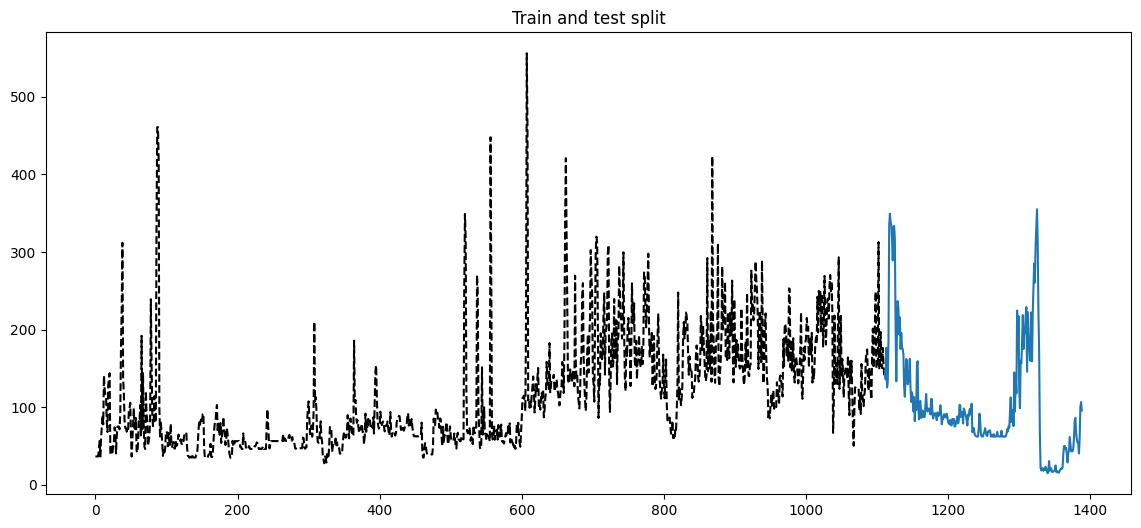

In [191]:
plt.figure(figsize=(14,6))
plt.plot(alandur_prophet_daily_train['y'] ,'k--')
plt.plot(alandur_prophet_daily_test['y'] )
plt.title("Train and test split")

In [192]:
# Initialize the Model
model=Prophet()
model.fit(alandur_prophet_daily_train)

09:48:36 - cmdstanpy - INFO - Chain [1] start processing
09:48:36 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
prediction = model.predict(alandur_prophet_daily_test)

prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-17,156.747215,116.983259,241.139539,156.747215,156.747215,22.376768,22.376768,22.376768,4.794333,4.794333,4.794333,17.582435,17.582435,17.582435,0.0,0.0,0.0,179.123982
1,2024-01-18,156.661174,111.948685,236.391435,156.661174,156.661174,18.553736,18.553736,18.553736,1.492255,1.492255,1.492255,17.061481,17.061481,17.061481,0.0,0.0,0.0,175.214910
2,2024-01-19,156.575133,111.568200,231.898731,156.575133,156.575133,16.980815,16.980815,16.980815,0.464392,0.464392,0.464392,16.516423,16.516423,16.516423,0.0,0.0,0.0,173.555948
3,2024-01-20,156.489092,109.118417,231.850892,156.489092,156.489092,15.208326,15.208326,15.208326,-0.762121,-0.762121,-0.762121,15.970447,15.970447,15.970447,0.0,0.0,0.0,171.697419
4,2024-01-21,156.403052,101.123775,229.746580,156.403052,156.403052,11.872783,11.872783,11.872783,-3.574506,-3.574506,-3.574506,15.447289,15.447289,15.447289,0.0,0.0,0.0,168.275835


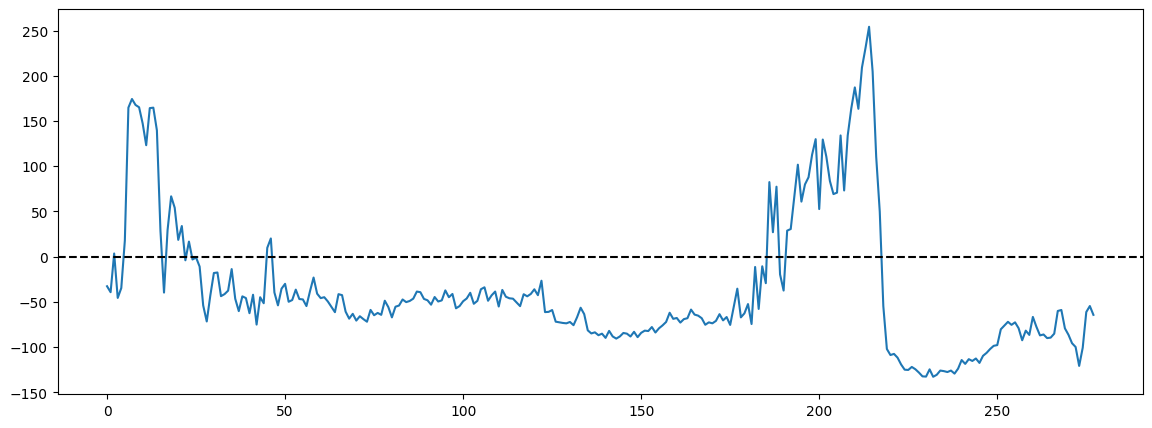

In [194]:
prediction['yhat'] = prediction['yhat'].astype(int)

residuals = alandur_prophet_daily_test['y'].values - prediction['yhat'].values

plt.figure(figsize=(14,5))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')

Text(0.5, 1.0, 'Prophet actual vs predicted')

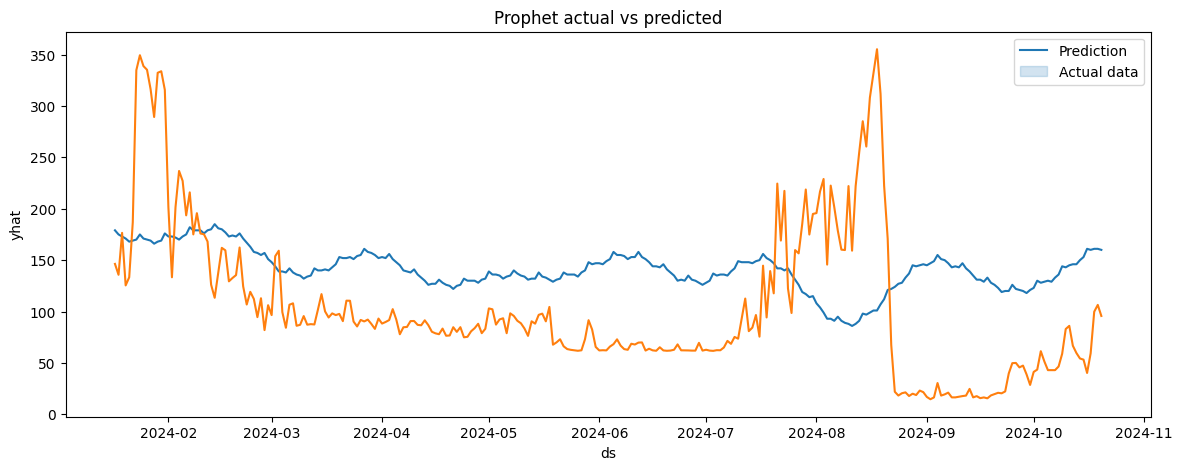

In [195]:
plt.figure(figsize=(14,5))
sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_daily_test, x='ds', y='y')
plt.legend(('Prediction','Actual data'))
plt.title("Prophet actual vs predicted")

<Axes: xlabel='ds', ylabel='yhat'>

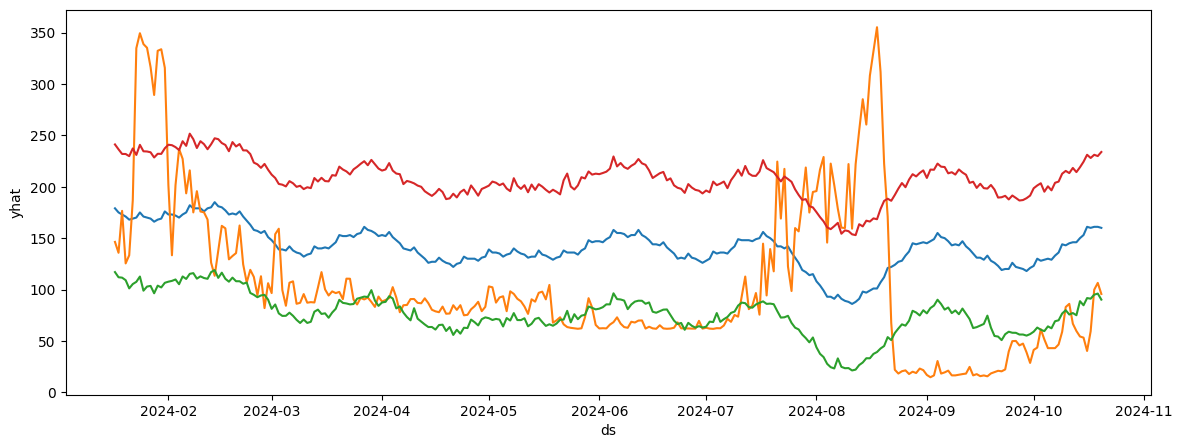

In [196]:
plt.figure(figsize=(14,5))
sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_daily_test, x='ds', y='y')
sns.lineplot(data = prediction, x='ds', y='yhat_lower')
sns.lineplot(data = prediction, x='ds', y='yhat_upper')
# plt.legend("Prophet actual vs predicted")

### Forecasting only 1 week

In [197]:
alandur_prophet_daily[:int(len(alandur_prophet_daily)*.98)]

,ds,y
0,2021-01-01,36.375000
1,2021-01-02,36.333333
2,2021-01-03,36.458333
3,2021-01-04,36.375000
4,2021-01-05,36.583333
...,...,...
1356,2024-09-18,15.583333
1357,2024-09-19,18.416667
1358,2024-09-20,19.666667
1359,2024-09-21,20.958333


In [198]:
alandur_prophet_daily_train = alandur_prophet_daily[:int(len(alandur_prophet_daily)*.98)]

alandur_prophet_daily_test = alandur_prophet_daily[int(len(alandur_prophet_daily)*.98):]

In [199]:
plt.figure(figsize=(14,6))
plt.plot(alandur_prophet_daily_train['y'] ,'k--')
plt.plot(alandur_prophet_daily_test['y'] )
plt.title("Train and test split")

Text(0.5, 1.0, 'Train and test split')

In [200]:
# Initialize the Model
model=Prophet()
model.fit(alandur_prophet_daily_train)

prediction = model.predict(alandur_prophet_daily_test)

prediction.head()

09:48:40 - cmdstanpy - INFO - Chain [1] start processing
09:48:40 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-09-23,90.323272,-0.755079,139.038015,90.323272,90.323272,-18.571956,-18.571956,-18.571956,-0.925490,-0.925490,-0.925490,-17.646466,-17.646466,-17.646466,0.0,0.0,0.0,71.751316
1,2024-09-24,90.115964,3.896695,144.461808,90.115964,90.115964,-16.519158,-16.519158,-16.519158,0.080751,0.080751,0.080751,-16.599909,-16.599909,-16.599909,0.0,0.0,0.0,73.596806
2,2024-09-25,89.908656,11.837277,155.073492,89.908656,89.908656,-10.773152,-10.773152,-10.773152,4.658375,4.658375,4.658375,-15.431528,-15.431528,-15.431528,0.0,0.0,0.0,79.135503
3,2024-09-26,89.701347,11.078642,148.600203,89.701347,89.701347,-13.976400,-13.976400,-13.976400,0.173010,0.173010,0.173010,-14.149410,-14.149410,-14.149410,0.0,0.0,0.0,75.724948
4,2024-09-27,89.494039,11.988137,149.966573,89.494039,89.494039,-12.902453,-12.902453,-12.902453,-0.140768,-0.140768,-0.140768,-12.761685,-12.761685,-12.761685,0.0,0.0,0.0,76.591587


In [201]:
prediction['yhat'] = prediction['yhat'].astype(int)
residuals = alandur_prophet_daily_test['y'].values - prediction['yhat'].values

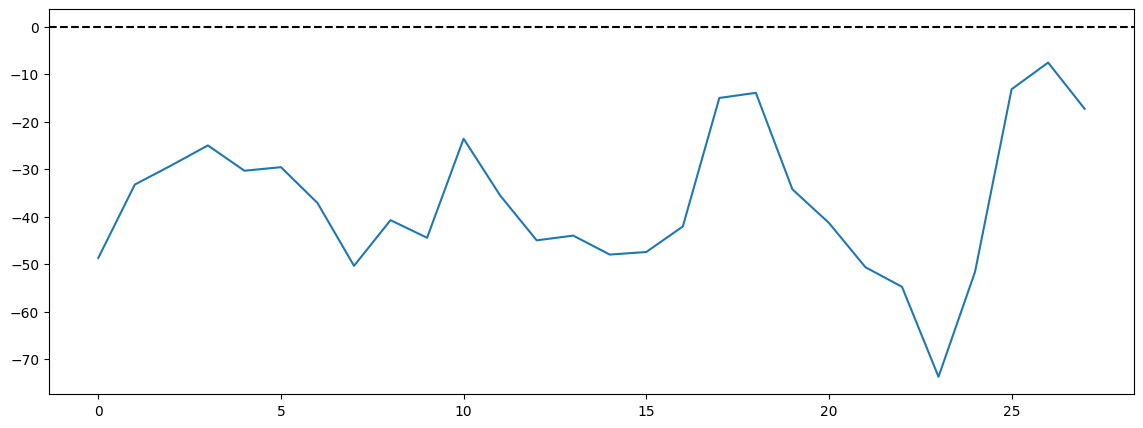

In [202]:
plt.figure(figsize=(14,5))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')

Text(0.5, 1.0, 'Prophet actual vs predicted')

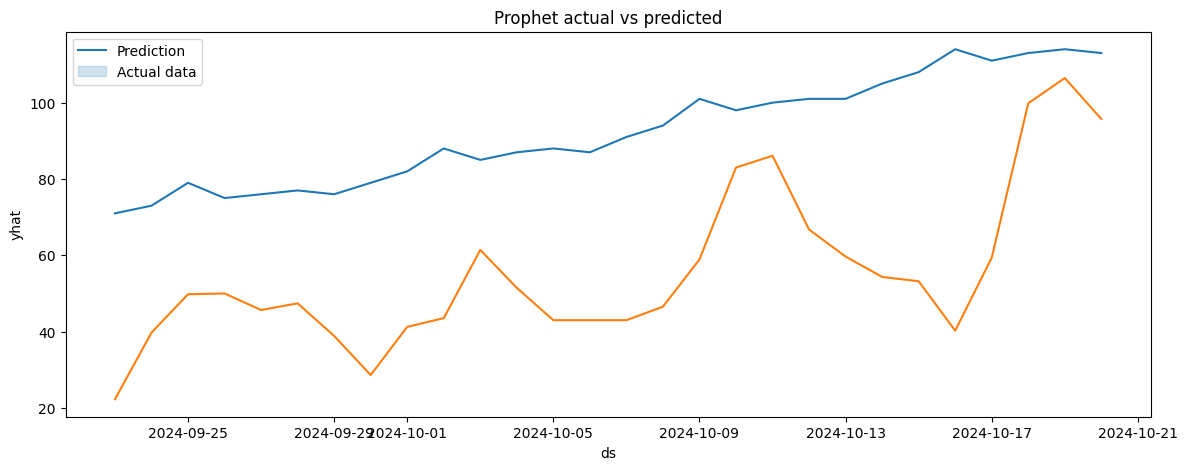

In [203]:
plt.figure(figsize=(14,5))
sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_daily_test, x='ds', y='y')
plt.legend(('Prediction','Actual data'))
plt.title("Prophet actual vs predicted")

<Axes: xlabel='ds', ylabel='y'>

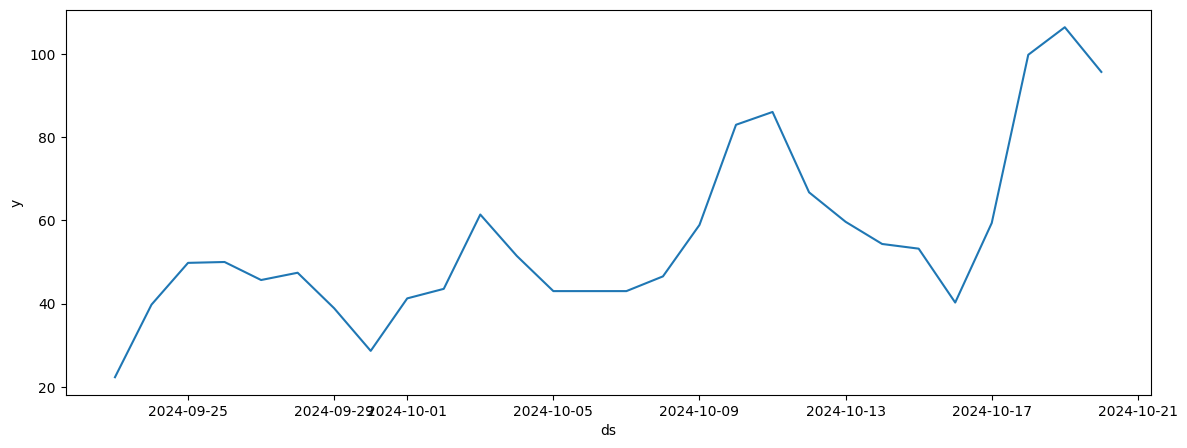

In [204]:
plt.figure(figsize=(14,5))
# sns.lineplot(data = prediction, x='ds', y='yhat')
sns.lineplot(data = alandur_prophet_daily_test, x='ds', y='y')
# plt.legend(('Prediction','Actual data'))
# plt.title("Prophet actual vs predicted")